In [39]:
"""
Nombre: Jairo Blanco
codigo: 2024114040
materia: Inteligencia Artificial
tema: Machine Learning - Supervised Learning - SVM
"""

'\nNombre: Jairo Blanco\ncodigo: 2024114040\nmateria: Inteligencia Artificial\ntema: Machine Learning - Supervised Learning - SVM\n'

# Taller 2 - Machine Learning - Support Vector Machine
En este taller vamos a realizar analisis con SVM.
Vamos a cargar las librerias

In [40]:
from sklearn import datasets # cargamos bases de datos
from sklearn.datasets import make_moons #esta es la base de datos para el SVM no lineal
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC #support vector clasificator
from sklearn.metrics import accuracy_score
import numpy as np #librerias para calculos y matematicas
import matplotlib.pyplot as plt # libreria visual para nube de dispersion
from mlxtend.plotting import plot_decision_regions #libreria visual para grafica de fronteras de desicion

# 1. SVM lineal: sensibilidad al parámetro C
a) Carga del dataset Wine; filtrado de las clases 0 y 1; selección explícita de dos columnas de características

In [41]:
wine = datasets.load_wine()
X = wine.data[:,[0,1]] #cargamos los 2 features
y = wine.target #junto a sus etiquetas de clasificación

mask = y < 2 # enmascaramos para extraer solo las 2 clases correspondientes a los 2 features
X = X[mask]
y = y[mask]

print(X.shape)  # acá tenemos los registros totales y cuantos features tiene (130 totales y 2 features)
print(np.bincount(y)) # acá vemos cuantos registros hay por clase

(130, 2)
[59 71]


b) Generación de una gráfica de dispersión previa al entrenamiento, con identificación visual de ambas clases

<function matplotlib.pyplot.show(close=None, block=None)>

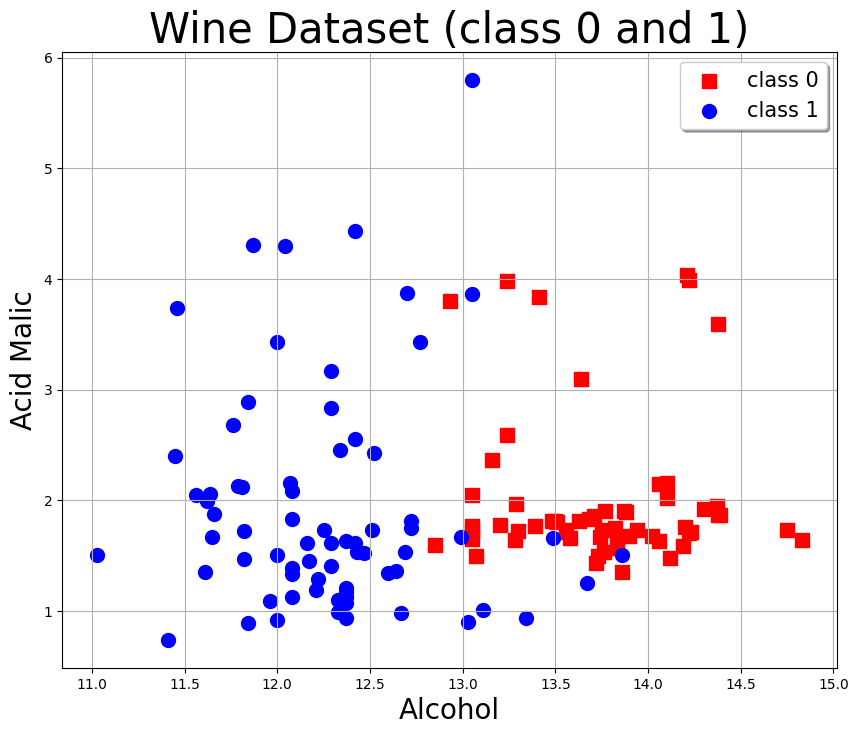

In [42]:
plt.figure(figsize=(10, 8))
plt.scatter(X[y==0,0],X[y==0,1],marker="s",color='red',s=100,label='class 0')
plt.scatter(X[y==1,0],X[y==1,1],marker="o",color='blue',s=100,label='class 1')
plt.title('Wine Dataset (class 0 and 1)', fontsize = 30)
plt.xlabel('Alcohol', fontsize = 20)
plt.ylabel('Acid Malic', fontsize = 20)
plt.legend(loc='best', shadow = True, fontsize = 15)
plt.grid(True)
plt.show

c) Partición 70/30 mediante train_test_split, con shuffle=True, stratify=y y random_state=1; estandarización a partir
de X_train.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,train_size=0.7,test_size=0.3,random_state=1,stratify = y, shuffle = True) #particion 70 para train y 30 para test
print(X_train.shape) # cantidad de datos (70 %) para los 2 features
print(X_test.shape) # cantidad de datos (30%) para los 2 features

(91, 2)
(39, 2)


d) Entrenamiento de tres modelos SVC(kernel="linear") con C=0.01, C=0.1 y C=10.0; cálculo de accuracy_score en
entrenamiento y prueba para cada configuración.


In [44]:
#Antes estandarizamos
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [45]:
#Ahora si configuramos modelos y entrenamos
model_svc_c1 = SVC(C=0.01, kernel = "linear", max_iter=1000,random_state=1) #modelo con C = 0.01
model_svc_c1.fit(X_train_std,y_train)

model_svc_c2 = SVC(C=0.1, kernel = "linear", max_iter=1000,random_state=1) #modelo con C = 0.1
model_svc_c2.fit(X_train_std,y_train)

model_svc_c3 = SVC(C=10.0, kernel = "linear", max_iter=1000,random_state=1) #modelo con c = 10.0
model_svc_c3.fit(X_train_std,y_train)


SVC(C=10.0, kernel='linear', max_iter=1000, random_state=1)

e) Construcción de tres regiones de decisión; tabla con C, accuracy de entrenamiento y accuracy de prueba;
predicción del dato np.array([[10.1, 2.5]]) tras transformación con el mismo StandardScaler.

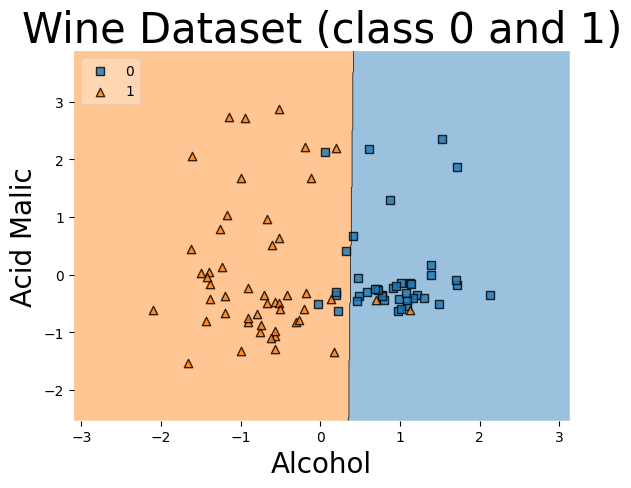

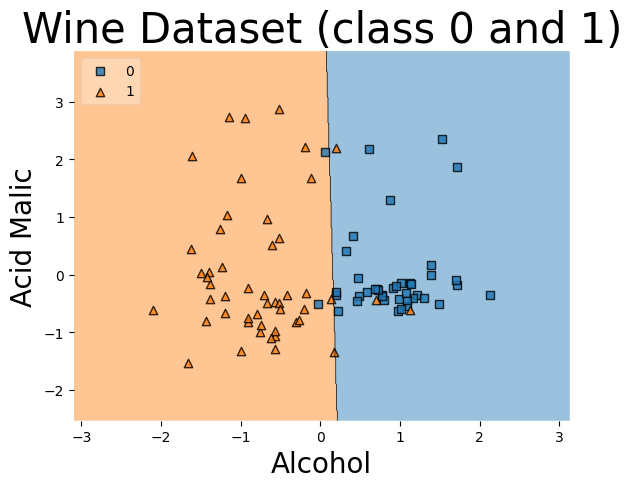

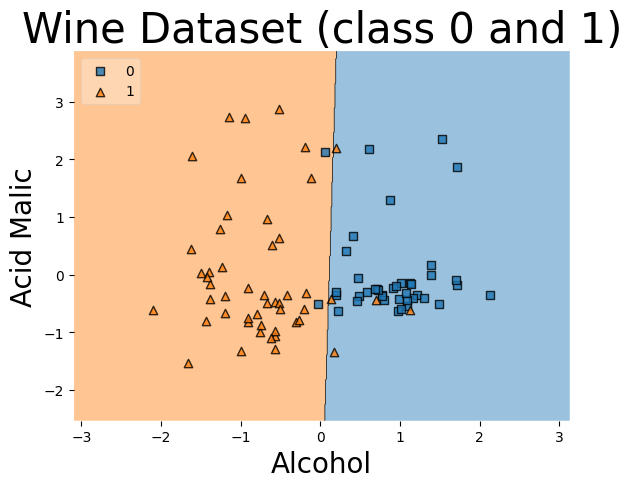

In [46]:
plot_decision_regions(X_train_std,y_train,clf=model_svc_c1,legend=2)
plt.xlabel('Alcohol', fontsize = 20)
plt.ylabel('Acid Malic', fontsize = 20)
plt.title('Wine Dataset (class 0 and 1)', fontsize = 30)
plt.show()

plot_decision_regions(X_train_std,y_train,clf=model_svc_c2,legend=2)
plt.xlabel('Alcohol', fontsize = 20)
plt.ylabel('Acid Malic', fontsize = 20)
plt.title('Wine Dataset (class 0 and 1)', fontsize = 30)
plt.show()

plot_decision_regions(X_train_std,y_train,clf=model_svc_c3,legend=2)
plt.xlabel('Alcohol', fontsize = 20)
plt.ylabel('Acid Malic', fontsize = 20)
plt.title('Wine Dataset (class 0 and 1)', fontsize = 30)
plt.show()

In [47]:
tasas = [0.01, 0.1, 10.0] # las 3 constantes de penalización de pesos pedidas por el taller
resultados = [] # acá guardamos los resultados para hacer las tablas

for c in tasas:
    model_svc = SVC(C=c, kernel = "linear", max_iter=1000,random_state=1)
    model_svc.fit(X_train_std,y_train)

    acc = accuracy_score(y_train, model_svc.predict(X_train_std))
    acc_test = accuracy_score(y_test, model_svc.predict(X_test_std))

    resultados.append({
        "Constante de penalizacion C ": c,
        "Acurracy de entrenamiento": acc,
        "Acurracy de prueba": acc_test
    })
tabla_comp = pd.DataFrame(resultados)
tabla_comp

,Constante de penalizacion C,Acurracy de entrenamiento,Acurracy de prueba
0,0.01,0.912088,0.871795
1,0.10,0.945055,0.897436
2,10.00,0.923077,0.923077


**Conclusion:** con los resultados de la tabla podemos observar que mientras mas grande es la constante de penalización mejor responde el acurracy de las pruebas, pero en el caso del acuracy de entrenamiento se estabiliza mejor cuando C = 0.10, dependiendo de los objetivos de nuestro campo podemos tomar una u otra. La relación entre C y las metricas de entrenamiento no es estrictamente creciente, mientras que por lo menos para los 3 ejemplos de C en el de prueba si.

In [48]:
new_data = np.array([[10.1, 2.5]])
new_data_std = sc.transform(new_data)
print(model_svc_c1.predict(new_data_std)) # vemos cual es la predicción para un nuevo vino, en este caso es clase 1

[1]


# 2. SVM RBF: variación controlada de C y gamma

a) Generación del conjunto no lineal y representación gráfica de las clases antes del entrenamiento.

<function matplotlib.pyplot.show(close=None, block=None)>

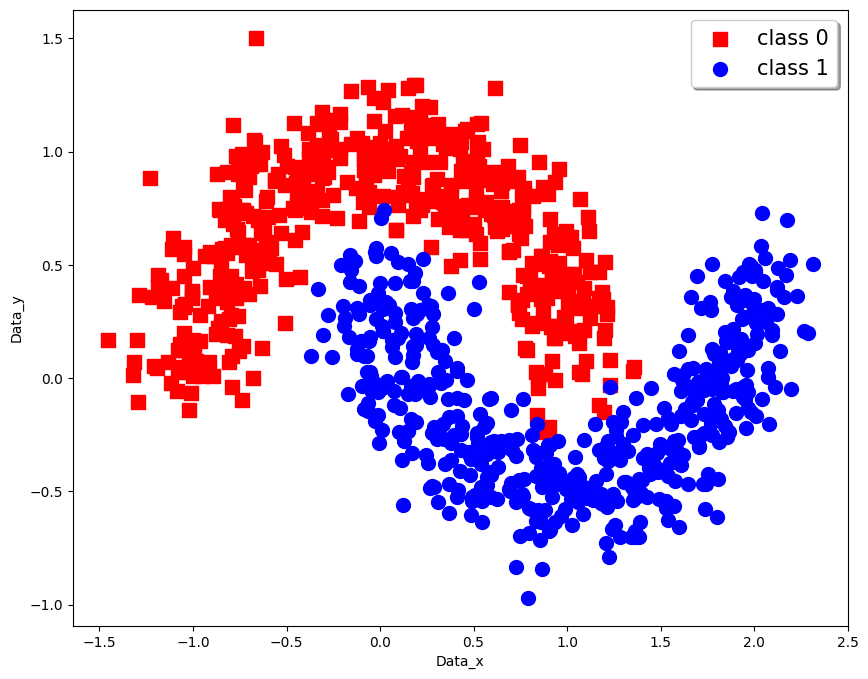

In [49]:
X, y = make_moons(n_samples=1000, noise=0.15, random_state=1)

plt.figure(figsize=(10, 8))
plt.scatter(X[y==0,0],X[y==0,1],marker="s",color='red',s=100,label='class 0')
plt.scatter(X[y==1,0],X[y==1,1],marker="o",color='blue',s=100,label='class 1')
plt.xlabel('Data_x')
plt.ylabel('Data_y')
plt.legend(loc='best', shadow = True, fontsize = 15)
plt.show

Partición 70/30 con estratificación; estandarización mediante StandardScaler ajustado exclusivamente con
X_train.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=1,stratify = y, shuffle = True)

print(X_train.shape) # vemos como el train tiene 700 registros (70 porciento)
print(X_test.shape) # mientras que el test tiene 300 registros (30 porciento)

(700, 2)
(300, 2)


c) Entrenamiento de cuatro modelos SVC(kernel="rbf") con las combinaciones: (C=0.1, γ="scale"), (C=1.0,
γ=0.1), (C=10.0, γ=0.5) y (C=100.0, γ=0.7).


In [51]:
#primero estandarizamos
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [81]:
model_svc_1 = SVC(C=0.1, kernel = "rbf", gamma = "scale", max_iter=1000,random_state=1)
model_svc_1.fit(X_train_std,y_train)

model_svc_2 = SVC(C=1.0, kernel = "rbf", gamma = 0.1, max_iter=1000,random_state=1)
model_svc_2.fit(X_train_std,y_train)

model_svc_3 = SVC(C=10.0, kernel = "rbf", gamma = 0.5, max_iter=1000,random_state=1)
model_svc_3.fit(X_train_std,y_train)

model_svc_4 = SVC(C=100.0, kernel = "rbf", gamma = 0.7, max_iter=1000,random_state=1)
model_svc_4.fit(X_train_std, y_train)

SVC(C=100.0, gamma=0.7, max_iter=1000, random_state=1)

d) Cálculo de accuracy_score en entrenamiento y prueba para las cuatro configuraciones.

In [82]:
acc_train_c1 = accuracy_score(y_train, model_svc_1.predict(X_train_std))
acc_test_c1 = accuracy_score(y_test, model_svc_1.predict(X_test_std))

acc_train_c2 = accuracy_score(y_train, model_svc_2.predict(X_train_std))
acc_test_c2 = accuracy_score(y_test, model_svc_2.predict(X_test_std))

acc_train_c3 = accuracy_score(y_train, model_svc_3.predict(X_train_std))
acc_test_c3 = accuracy_score(y_test, model_svc_3.predict(X_test_std))

acc_train_c4 = accuracy_score(y_train, model_svc_4.predict(X_train_std))
acc_test_c4 = accuracy_score(y_test, model_svc_4.predict(X_test_std))

print(acc_train_c1, acc_test_c1)
print(acc_train_c2, acc_test_c2)
print(acc_train_c3, acc_test_c3)
print(acc_train_c4, acc_test_c4)

0.9571428571428572 0.9566666666666667
0.91 0.8933333333333333
0.9914285714285714 0.98
0.9957142857142857 0.9866666666666667


e) Representación de las cuatro regiones de decisión; tabla comparativa con C, gamma, accuracy de entrenamiento
y accuracy de prueba; predicción de new_data=np.array([[1.1, -1.0]]) tras transformación con el mismo
StandardScaler.

<function matplotlib.pyplot.show(close=None, block=None)>

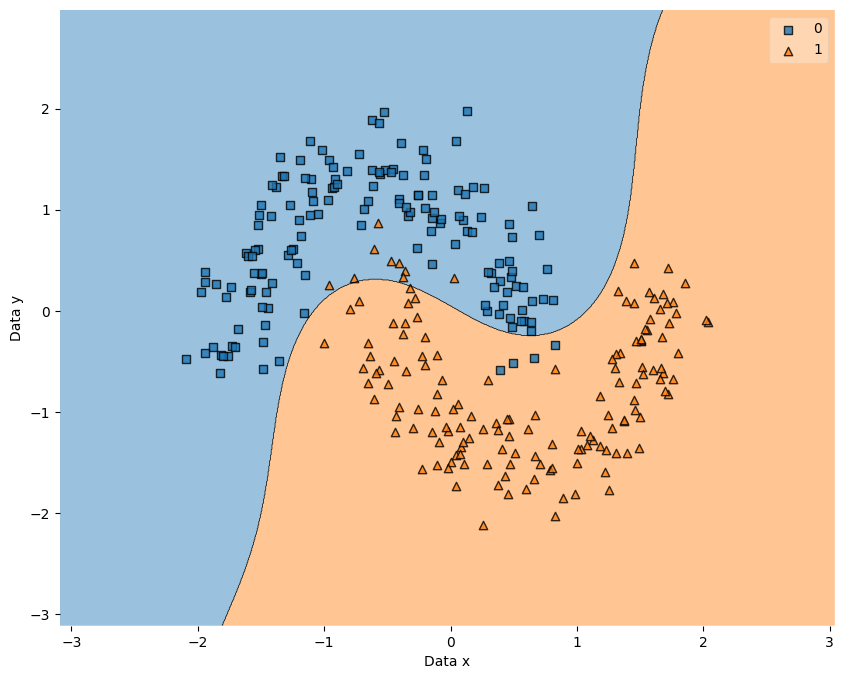

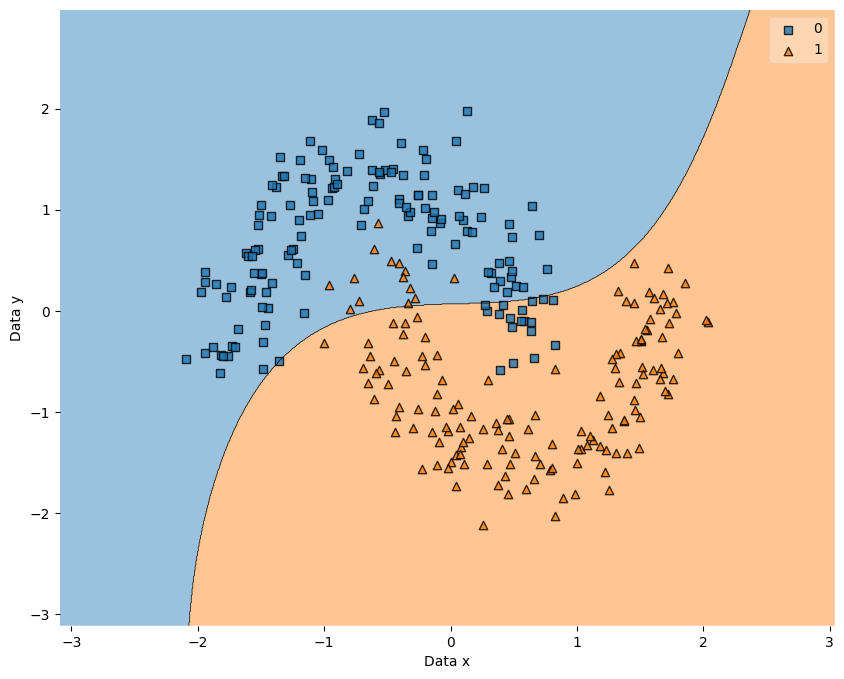

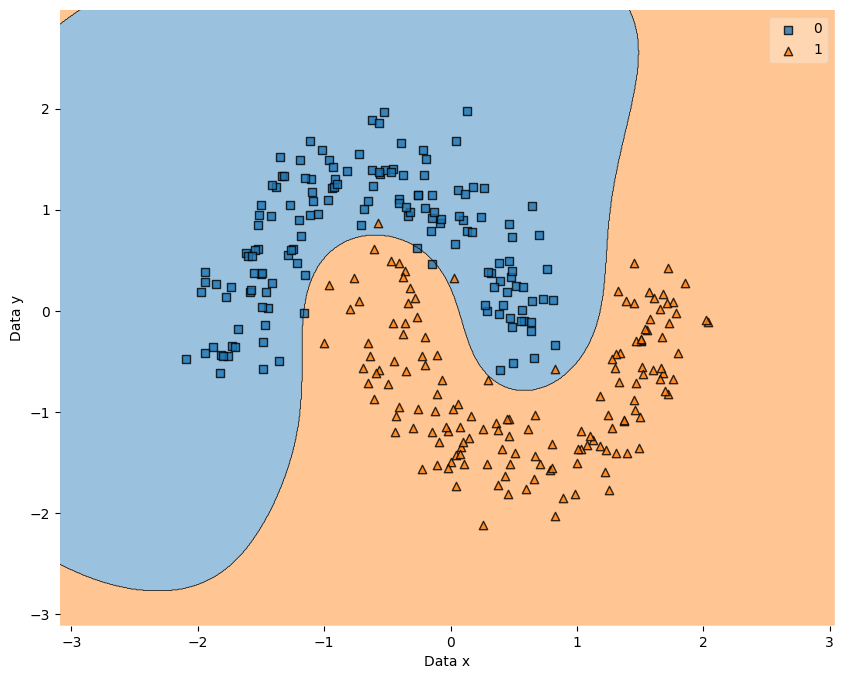

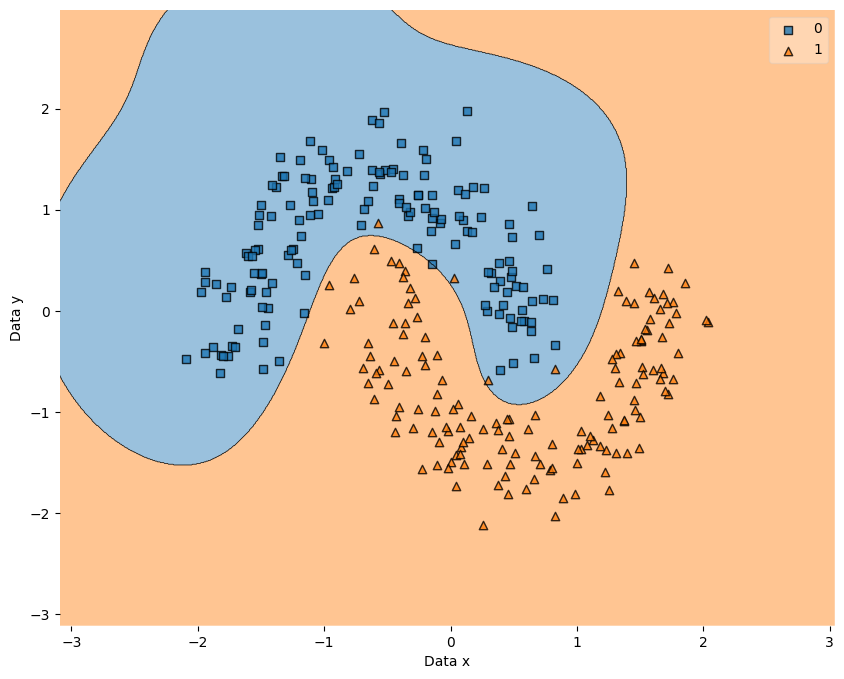

In [83]:
plt.figure(figsize=(10, 8))
plot_decision_regions(X_test_std,y_test,clf=model_svc_1)
plt.xlabel('Data x')
plt.ylabel('Data y')
plt.show

plt.figure(figsize=(10, 8))
plot_decision_regions(X_test_std,y_test,clf=model_svc_2)
plt.xlabel('Data x')
plt.ylabel('Data y')
plt.show

plt.figure(figsize=(10, 8))
plot_decision_regions(X_test_std,y_test,clf=model_svc_3)
plt.xlabel('Data x')
plt.ylabel('Data y')
plt.show

plt.figure(figsize=(10, 8))
plot_decision_regions(X_test_std,y_test,clf=model_svc_4)
plt.xlabel('Data x')
plt.ylabel('Data y')
plt.show

prepara,os dataframe

In [80]:
aprendizaje = [(0.1, "scale"), (1.0, 0.1), (10.0, 0.5), (100.0, 0.7)]
results = []
for i in aprendizaje:
  c, g = i #desempaquetamos la tupla
  model_svc = SVC(C=c, kernel = "rbf", gamma = g, max_iter=1000,random_state=1)
  model_svc.fit(X_train_std,y_train)

  acc = accuracy_score(y_train, model_svc.predict(X_train_std))
  acc_test = accuracy_score(y_test, model_svc.predict(X_test_std))

  results.append({
      "Constante de penalizacion C ": c,
      "Gamma": g,
      "Acurracy de entrenamiento": acc,
      "Acurracy de prueba": acc_test
  })

tabla_comp = pd.DataFrame(results) #cargamos la tabla de resultados
tabla_comp

,Constante de penalizacion C,Gamma,Acurracy de entrenamiento,Acurracy de prueba
0,0.1,scale,0.957143,0.956667
1,1.0,0.1,0.910000,0.893333
2,10.0,0.5,0.991429,0.980000
3,100.0,0.7,0.995714,0.986667


In [67]:
new_data = np.array([[1.1, -1.0]])
new_data_std = new_data_std = sc.transform(new_data)
print(model_svc_3.predict(new_data_std)) # en este caso el nuevo dato pertenece a la clase 1


[1]


**conclusion:** en este caso vemos que mientras mas grande es la penalización de C y su relación con gamma mejor es la calidad de las predicciones del modelo, en cuanto a las fronteras vemos que mientras mas grandes son estas constantes mejor se ajustan a los hiperparametros, segmentando mucho mejor cada clase

# 3. Comparación experimental: kernel lineal frente a kernel RBF

a) Preparación de X_train, X_test, y_train y y_test mediante una única partición; estandarización común para
ambos modelos.


In [91]:
X_train, X_test, y_train, y_test = train_test_split( #particion unica para ambos modelos
    X,y,train_size=0.7,test_size=0.3,random_state=1,stratify = y, shuffle = True) #particion 70 para train y 30 para test
print(X_train.shape) # cantidad de datos (70 %) para los 2 features
print(X_test.shape) # cantidad de datos (30%) para los 2 features

#ahora estandarizamos
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

(700, 2)
(300, 2)


b) Entrenamiento de SVC(C=1.0, kernel="linear", random_state=1) y SVC(C=1.0, kernel="rbf", gamma="scale",
random_state=1).

In [92]:
linear_model = SVC(C=1.0, kernel="linear", random_state=1)
linear_model.fit(X_train_std,y_train)

rbf_model = SVC(C=1.0, kernel="rbf", gamma="scale", random_state=1)
rbf_model.fit(X_train_std,y_train)

SVC(random_state=1)

c) Cálculo de accuracy_score en entrenamiento y prueba para ambos modelos.

In [93]:
acc_train_linear = accuracy_score(y_train, linear_model.predict(X_train_std))
acc_test_linear = accuracy_score(y_test, linear_model.predict(X_test_std))

acc_train_rbf = accuracy_score(y_train, rbf_model.predict(X_train_std))
acc_test_rbf = accuracy_score(y_test, rbf_model.predict(X_test_std))

print(acc_train_linear, acc_test_linear)
print(acc_train_rbf, acc_test_rbf)

0.8714285714285714 0.87
0.9871428571428571 0.9866666666666667


d) Representación independiente de las regiones de decisión del kernel lineal y del kernel RBF.

<function matplotlib.pyplot.show(close=None, block=None)>

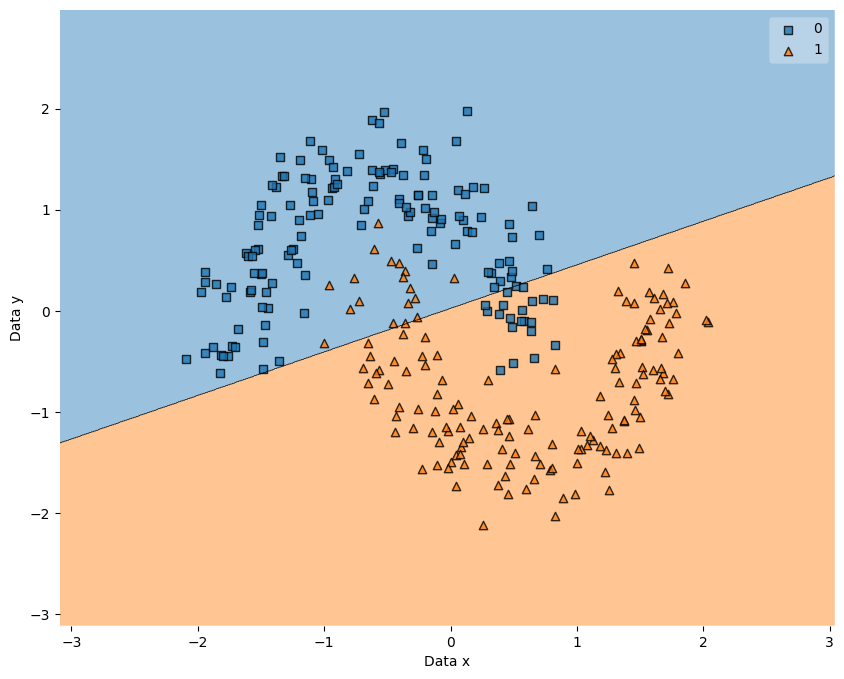

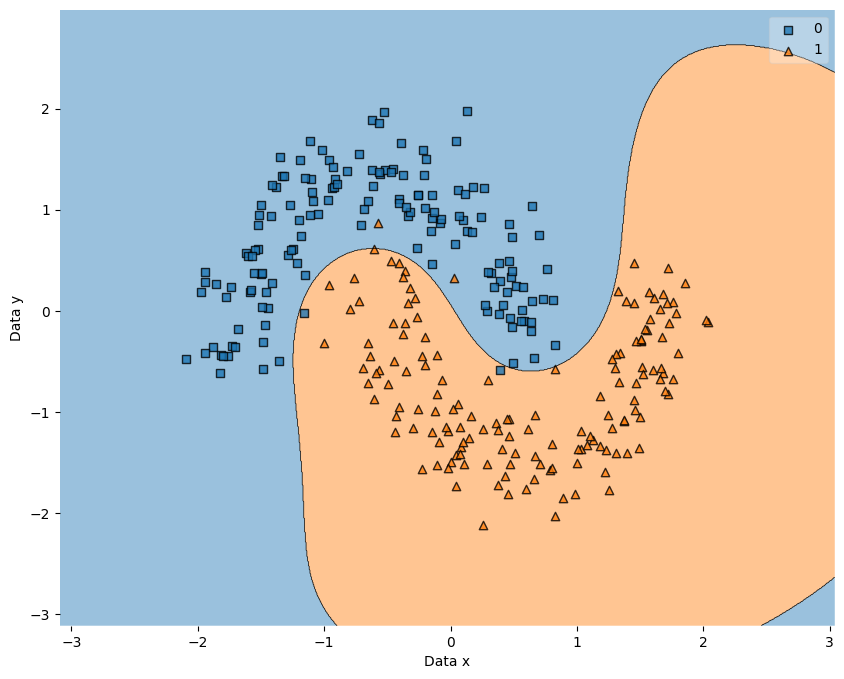

In [94]:
plt.figure(figsize=(10, 8))
plot_decision_regions(X_test_std,y_test,clf=linear_model)
plt.xlabel('Data x')
plt.ylabel('Data y')
plt.show

plt.figure(figsize=(10, 8))
plot_decision_regions(X_test_std,y_test,clf=rbf_model)
plt.xlabel('Data x')
plt.ylabel('Data y')
plt.show

e) Comparación de las predicciones generadas por ambos modelos para new_data=np.array([[1.1, -1.0]]), con
transformación previa mediante el mismo StandardScaler del entrenamiento.

In [95]:
new_data=np.array([[1.1, -1.0]])
new_data_std = sc.transform(new_data)
print(linear_model.predict(new_data_std))
print(rbf_model.predict(new_data_std))

[1]
[1]


**Conclusion:** aunque los 2 modelos aciertan la predicción observamos que el lineal no posee una excelente capacidad de separación debido a la naturaleza primitiva no lineal de los datos, tal como observamos en la disperción. Esto hace que el modelo no lineal sobrepase muchisimo al lineal en este caso, demostrandose con casi una diferencia de 11 puntos porcentuales (siendo obviamente el mas alto el no lineal).